# MAUS Dataset Preprocessing
## Uncertainty-Aware Mental Workload Classification for Wearables

This notebook preprocesses the MAUS dataset for workload classification:
1. Load raw physiological signals (ECG, fingertip PPG, wrist PPG, GSR) per trial
2. Apply bandpass filtering and artifact removal
3. Segment into fixed-length windows with workload labels (0-back / 2-back / 3-back)
4. Extract per-window features (optional HRV baseline) and save windowed tensors
5. Merge subjective NASA-TLX ratings for auxiliary analysis

In [1]:
import os
import glob
import numpy as np
import pandas as pd
from scipy.signal import butter, filtfilt, iirnotch
from scipy.stats import zscore
import warnings
warnings.filterwarnings('ignore')

# --- Configuration ---
BASE_DIR = os.path.dirname(os.path.abspath('__file__'))  # MAUS/
RAW_DIR = os.path.join(BASE_DIR, 'Data', 'Raw_data')
IBI_DIR = os.path.join(BASE_DIR, 'Data', 'IBI_sequence')
SUBJ_DIR = os.path.join(BASE_DIR, 'Subjective_rating')
OUTPUT_DIR = os.path.join(BASE_DIR, 'preprocessed')
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Sampling rates
FS_INF = 256    # Infrared sensors: ECG, fingertip PPG, GSR
FS_PIX = 100    # PixArt wrist PPG

# Windowing parameters
WINDOW_SEC = 10        # Window length in seconds
OVERLAP_RATIO = 0.5    # 50% overlap between consecutive windows

# Target resampling rate (resample wrist PPG up to match infrared)
FS_TARGET = 256

# Trial-to-condition mapping (from column headers)
# Each raw CSV has columns: Trial 1:0back, Trial 2:2back, Trial 3:3back,
#                           Trial 4:2back, Trial 5:3back, Trial 6:0back
TRIAL_CONDITION = {
    0: 0,   # Trial 1 -> 0-back
    1: 2,   # Trial 2 -> 2-back
    2: 3,   # Trial 3 -> 3-back
    3: 2,   # Trial 4 -> 2-back
    4: 3,   # Trial 5 -> 3-back
    5: 0,   # Trial 6 -> 0-back
}

# Map n-back level to class index
LABEL_MAP = {0: 0, 2: 1, 3: 2}  # 0-back=0, 2-back=1, 3-back=2

PARTICIPANT_IDS = sorted([
    d for d in os.listdir(RAW_DIR)
    if os.path.isdir(os.path.join(RAW_DIR, d)) and d != '.DS_Store'
])

print(f"Found {len(PARTICIPANT_IDS)} participants: {PARTICIPANT_IDS}")
print(f"Window: {WINDOW_SEC}s, Overlap: {OVERLAP_RATIO*100:.0f}%, Target Fs: {FS_TARGET} Hz")

Found 22 participants: ['002', '003', '004', '005', '006', '008', '010', '011', '012', '013', '014', '015', '016', '017', '018', '019', '020', '021', '022', '023', '024', '025']
Window: 10s, Overlap: 50%, Target Fs: 256 Hz


## 1. Filtering Utilities

Each signal type needs different bandpass filtering:
- **ECG**: 0.5 - 40 Hz (standard clinical range)
- **PPG (fingertip & wrist)**: 0.5 - 8 Hz (pulse wave)
- **GSR/EDA**: 0.05 - 5 Hz (tonic + phasic components)

In [2]:
def bandpass_filter(signal, lowcut, highcut, fs, order=4):
    """Apply zero-phase Butterworth bandpass filter."""
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    # Clamp to valid range
    low = max(low, 1e-5)
    high = min(high, 1.0 - 1e-5)
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, signal)


def notch_filter(signal, freq, fs, Q=30):
    """Remove powerline interference."""
    b, a = iirnotch(freq, Q, fs)
    return filtfilt(b, a, signal)


# Signal-specific filter configs
FILTER_PARAMS = {
    'ecg':      {'lowcut': 0.5,  'highcut': 40.0},
    'ppg_inf':  {'lowcut': 0.5,  'highcut': 8.0},
    'ppg_pix':  {'lowcut': 0.5,  'highcut': 8.0},
    'gsr':      {'lowcut': 0.05, 'highcut': 5.0},
}


def filter_signal(signal, signal_type, fs):
    """Apply appropriate bandpass + 50Hz notch filter for a signal type."""
    params = FILTER_PARAMS[signal_type]
    # Notch filter for powerline noise (only relevant if fs > 2*50)
    if fs > 100:
        signal = notch_filter(signal, 50.0, fs)
    # Bandpass
    signal = bandpass_filter(signal, params['lowcut'], params['highcut'], fs)
    return signal


print("Filter configurations:")
for k, v in FILTER_PARAMS.items():
    print(f"  {k}: {v['lowcut']} - {v['highcut']} Hz")

Filter configurations:
  ecg: 0.5 - 40.0 Hz
  ppg_inf: 0.5 - 8.0 Hz
  ppg_pix: 0.5 - 8.0 Hz
  gsr: 0.05 - 5.0 Hz


## 2. Artifact Detection & Removal

Simple z-score based artifact detection: samples beyond a threshold are replaced
with interpolated values. Windows with too many artifacts are flagged for exclusion.

In [3]:
ARTIFACT_ZSCORE_THRESH = 5.0    # Flag samples with |z| > 5
ARTIFACT_MAX_RATIO = 0.3        # Reject window if > 30% samples are artifacts


def detect_and_interpolate_artifacts(signal, z_thresh=ARTIFACT_ZSCORE_THRESH):
    """
    Detect artifact samples via z-score threshold and replace with
    linear interpolation. Returns cleaned signal and artifact ratio.
    """
    z = np.abs(zscore(signal, nan_policy='omit'))
    artifact_mask = z > z_thresh
    artifact_ratio = artifact_mask.sum() / len(signal)

    if artifact_mask.any():
        clean = signal.copy()
        good_idx = np.where(~artifact_mask)[0]
        bad_idx = np.where(artifact_mask)[0]
        if len(good_idx) >= 2:
            clean[bad_idx] = np.interp(bad_idx, good_idx, clean[good_idx])
        return clean, artifact_ratio
    return signal, artifact_ratio


print(f"Artifact z-score threshold: {ARTIFACT_ZSCORE_THRESH}")
print(f"Max artifact ratio per window: {ARTIFACT_MAX_RATIO}")

Artifact z-score threshold: 5.0
Max artifact ratio per window: 0.3


## 3. Resampling Utility

The wrist PPG (PixArt) is sampled at 100 Hz while infrared sensors are at 256 Hz.
For multi-modal fusion we resample wrist PPG to 256 Hz.

In [4]:
from scipy.signal import resample


def resample_signal(signal, fs_original, fs_target):
    """Resample signal to target sampling rate."""
    if fs_original == fs_target:
        return signal
    num_samples_target = int(len(signal) * fs_target / fs_original)
    return resample(signal, num_samples_target)


# Verify: 5000 samples at 100 Hz -> should become ~12800 at 256 Hz
test = np.random.randn(5000)
resampled = resample_signal(test, 100, 256)
print(f"Resample test: {len(test)} samples @ 100Hz -> {len(resampled)} samples @ 256Hz")

Resample test: 5000 samples @ 100Hz -> 12800 samples @ 256Hz


## 4. Load & Process Raw Signals Per Participant

For each participant, we load the 4 signal types across 6 trials, apply filtering,
artifact cleaning, and resampling.

In [5]:
def load_raw_signals(pid):
    """
    Load all raw signals for a participant.
    
    Returns:
        dict of {trial_idx: {'ecg': array, 'ppg_inf': array, 
                             'ppg_pix': array, 'gsr': array,
                             'condition': int}}
        Each array is filtered, artifact-cleaned, and resampled to FS_TARGET.
    """
    pdir = os.path.join(RAW_DIR, pid)
    
    # Load CSVs — each has 6 columns (one per trial)
    ecg_df = pd.read_csv(os.path.join(pdir, 'inf_ecg.csv'))
    ppg_inf_df = pd.read_csv(os.path.join(pdir, 'inf_ppg.csv'))
    ppg_pix_df = pd.read_csv(os.path.join(pdir, 'pixart.csv'))
    gsr_df = pd.read_csv(os.path.join(pdir, 'inf_gsr.csv'))
    
    trials = {}
    for trial_idx in range(6):
        condition = TRIAL_CONDITION[trial_idx]
        
        # Extract trial column (by position)
        ecg_raw = ecg_df.iloc[:, trial_idx].values.astype(float)
        ppg_inf_raw = ppg_inf_df.iloc[:, trial_idx].values.astype(float)
        ppg_pix_raw = ppg_pix_df.iloc[:, trial_idx].values.astype(float)
        gsr_raw = gsr_df.iloc[:, trial_idx].values.astype(float)
        
        # Drop NaN rows (some trials may have trailing NaNs)
        ecg_raw = ecg_raw[~np.isnan(ecg_raw)]
        ppg_inf_raw = ppg_inf_raw[~np.isnan(ppg_inf_raw)]
        ppg_pix_raw = ppg_pix_raw[~np.isnan(ppg_pix_raw)]
        gsr_raw = gsr_raw[~np.isnan(gsr_raw)]
        
        # Filter
        ecg_filt = filter_signal(ecg_raw, 'ecg', FS_INF)
        ppg_inf_filt = filter_signal(ppg_inf_raw, 'ppg_inf', FS_INF)
        ppg_pix_filt = filter_signal(ppg_pix_raw, 'ppg_pix', FS_PIX)
        gsr_filt = filter_signal(gsr_raw, 'gsr', FS_INF)
        
        # Artifact cleaning
        ecg_clean, _ = detect_and_interpolate_artifacts(ecg_filt)
        ppg_inf_clean, _ = detect_and_interpolate_artifacts(ppg_inf_filt)
        ppg_pix_clean, _ = detect_and_interpolate_artifacts(ppg_pix_filt)
        gsr_clean, _ = detect_and_interpolate_artifacts(gsr_filt)
        
        # Resample wrist PPG from 100 Hz -> 256 Hz
        ppg_pix_resampled = resample_signal(ppg_pix_clean, FS_PIX, FS_TARGET)
        
        # Z-normalize each signal (zero mean, unit variance)
        ecg_norm = zscore(ecg_clean)
        ppg_inf_norm = zscore(ppg_inf_clean)
        ppg_pix_norm = zscore(ppg_pix_resampled)
        gsr_norm = zscore(gsr_clean)
        
        trials[trial_idx] = {
            'ecg': ecg_norm,
            'ppg_inf': ppg_inf_norm,
            'ppg_pix': ppg_pix_norm,
            'gsr': gsr_norm,
            'condition': condition,
        }
    
    return trials


# Quick test on one participant
test_trials = load_raw_signals(PARTICIPANT_IDS[0])
for tidx, tdata in test_trials.items():
    print(f"  Trial {tidx+1} ({tdata['condition']}-back): "
          f"ECG={len(tdata['ecg'])}, PPG_inf={len(tdata['ppg_inf'])}, "
          f"PPG_pix={len(tdata['ppg_pix'])}, GSR={len(tdata['gsr'])}")

  Trial 1 (0-back): ECG=76800, PPG_inf=76800, PPG_pix=78720, GSR=76800
  Trial 2 (2-back): ECG=76800, PPG_inf=76800, PPG_pix=78720, GSR=76800
  Trial 3 (3-back): ECG=76800, PPG_inf=76800, PPG_pix=78720, GSR=76800
  Trial 4 (2-back): ECG=76800, PPG_inf=76800, PPG_pix=78720, GSR=76800
  Trial 5 (3-back): ECG=76800, PPG_inf=76800, PPG_pix=78720, GSR=76800
  Trial 6 (0-back): ECG=76800, PPG_inf=76800, PPG_pix=78720, GSR=76800


## 5. Windowing

Segment each trial into fixed-length overlapping windows.
Signals of different lengths (after resampling) are truncated to the shortest
common length before windowing.

In [6]:
def create_windows(trial_data, window_sec=WINDOW_SEC, overlap=OVERLAP_RATIO, fs=FS_TARGET):
    """
    Segment trial signals into overlapping windows.
    
    Returns:
        windows: list of dicts, each with signal arrays and metadata
    """
    window_len = int(window_sec * fs)
    step = int(window_len * (1 - overlap))
    
    # Truncate all signals to the shortest common length
    min_len = min(
        len(trial_data['ecg']),
        len(trial_data['ppg_inf']),
        len(trial_data['ppg_pix']),
        len(trial_data['gsr']),
    )
    
    windows = []
    start = 0
    while start + window_len <= min_len:
        end = start + window_len
        
        w_ecg = trial_data['ecg'][start:end]
        w_ppg_inf = trial_data['ppg_inf'][start:end]
        w_ppg_pix = trial_data['ppg_pix'][start:end]
        w_gsr = trial_data['gsr'][start:end]
        
        # Check artifact quality in window
        _, art_ecg = detect_and_interpolate_artifacts(w_ecg)
        _, art_ppg = detect_and_interpolate_artifacts(w_ppg_inf)
        _, art_pix = detect_and_interpolate_artifacts(w_ppg_pix)
        max_art = max(art_ecg, art_ppg, art_pix)
        
        windows.append({
            'ecg': w_ecg,
            'ppg_inf': w_ppg_inf,
            'ppg_pix': w_ppg_pix,
            'gsr': w_gsr,
            'condition': trial_data['condition'],
            'label': LABEL_MAP[trial_data['condition']],
            'artifact_ratio': max_art,
            'is_clean': max_art < ARTIFACT_MAX_RATIO,
        })
        start += step
    
    return windows


# Test windowing on first participant, first trial
test_windows = create_windows(test_trials[0])
print(f"Trial 1 -> {len(test_windows)} windows of {WINDOW_SEC}s @ {FS_TARGET}Hz "
      f"({WINDOW_SEC * FS_TARGET} samples each)")
print(f"Clean windows: {sum(w['is_clean'] for w in test_windows)}/{len(test_windows)}")

Trial 1 -> 59 windows of 10s @ 256Hz (2560 samples each)
Clean windows: 59/59


## 6. Process All Participants → Build Dataset

Iterate over all participants, load signals, window them, and collect into arrays.

In [7]:
all_windows = []
window_len_samples = WINDOW_SEC * FS_TARGET

for pid in PARTICIPANT_IDS:
    print(f"Processing {pid}...", end=' ')
    try:
        trials = load_raw_signals(pid)
    except Exception as e:
        print(f"FAILED: {e}")
        continue
    
    n_windows = 0
    for trial_idx, trial_data in trials.items():
        windows = create_windows(trial_data)
        for w in windows:
            w['participant'] = pid
            w['trial'] = trial_idx
        all_windows.extend(windows)
        n_windows += len(windows)
    
    print(f"{n_windows} windows")

print(f"\nTotal windows: {len(all_windows)}")
print(f"Clean windows: {sum(w['is_clean'] for w in all_windows)}")
print(f"Label distribution:")
for label_name, label_val in LABEL_MAP.items():
    count = sum(1 for w in all_windows if w['label'] == label_val)
    print(f"  {label_name}-back (label={label_val}): {count}")

Processing 002... 354 windows
Processing 003... 354 windows
Processing 004... 354 windows
Processing 005... 354 windows
Processing 006... 354 windows
Processing 008... 354 windows
Processing 010... 354 windows
Processing 011... 354 windows
Processing 012... 354 windows
Processing 013... 354 windows
Processing 014... 354 windows
Processing 015... 354 windows
Processing 016... 354 windows
Processing 017... 354 windows
Processing 018... 354 windows
Processing 019... 354 windows
Processing 020... 354 windows
Processing 021... 354 windows
Processing 022... 354 windows
Processing 023... 354 windows
Processing 024... 354 windows
Processing 025... 354 windows

Total windows: 7788
Clean windows: 7788
Label distribution:
  0-back (label=0): 2596
  2-back (label=1): 2596
  3-back (label=2): 2596


## 7. Assemble into NumPy Arrays

Create separate arrays for each modality (for cross-modality experiments)
and a fused multi-channel array.

In [8]:
n = len(all_windows)
W = window_len_samples

# Individual modality arrays: shape (N, 1, W)
X_ecg = np.zeros((n, 1, W), dtype=np.float32)
X_ppg_inf = np.zeros((n, 1, W), dtype=np.float32)
X_ppg_pix = np.zeros((n, 1, W), dtype=np.float32)
X_gsr = np.zeros((n, 1, W), dtype=np.float32)

# Fused array: shape (N, 4, W) — [ECG, PPG_inf, PPG_pix, GSR]
X_fused = np.zeros((n, 4, W), dtype=np.float32)

# PPG+GSR fusion (for sensor-fusion experiment): shape (N, 3, W)
X_ppg_gsr = np.zeros((n, 3, W), dtype=np.float32)

# Labels and metadata
y = np.zeros(n, dtype=np.int64)
participants = []
trial_ids = []
is_clean = np.zeros(n, dtype=bool)
artifact_ratios = np.zeros(n, dtype=np.float32)

for i, w in enumerate(all_windows):
    X_ecg[i, 0, :] = w['ecg'][:W]
    X_ppg_inf[i, 0, :] = w['ppg_inf'][:W]
    X_ppg_pix[i, 0, :] = w['ppg_pix'][:W]
    X_gsr[i, 0, :] = w['gsr'][:W]
    
    X_fused[i, 0, :] = w['ecg'][:W]
    X_fused[i, 1, :] = w['ppg_inf'][:W]
    X_fused[i, 2, :] = w['ppg_pix'][:W]
    X_fused[i, 3, :] = w['gsr'][:W]
    
    X_ppg_gsr[i, 0, :] = w['ppg_inf'][:W]
    X_ppg_gsr[i, 1, :] = w['ppg_pix'][:W]
    X_ppg_gsr[i, 2, :] = w['gsr'][:W]
    
    y[i] = w['label']
    participants.append(w['participant'])
    trial_ids.append(w['trial'])
    is_clean[i] = w['is_clean']
    artifact_ratios[i] = w['artifact_ratio']

participants = np.array(participants)
trial_ids = np.array(trial_ids)

print(f"X_ecg:      {X_ecg.shape}")
print(f"X_ppg_inf:  {X_ppg_inf.shape}")
print(f"X_ppg_pix:  {X_ppg_pix.shape}")
print(f"X_gsr:      {X_gsr.shape}")
print(f"X_fused:    {X_fused.shape}")
print(f"X_ppg_gsr:  {X_ppg_gsr.shape}")
print(f"y:          {y.shape}, classes: {np.unique(y, return_counts=True)}")
print(f"Clean mask: {is_clean.sum()}/{len(is_clean)}")

X_ecg:      (7788, 1, 2560)
X_ppg_inf:  (7788, 1, 2560)
X_ppg_pix:  (7788, 1, 2560)
X_gsr:      (7788, 1, 2560)
X_fused:    (7788, 4, 2560)
X_ppg_gsr:  (7788, 3, 2560)
y:          (7788,), classes: (array([0, 1, 2]), array([2596, 2596, 2596]))
Clean mask: 7788/7788


## 8. Load Subjective Ratings (NASA-TLX & PSQI)

Load NASA-TLX weighted workload scores per participant per trial, and PSQI scores.
These can serve as auxiliary features or for post-hoc analysis.

In [9]:
def load_nasa_tlx(pid):
    """Load NASA-TLX adjusted weighted ratings for a participant."""
    fpath = os.path.join(SUBJ_DIR, pid, 'NASA_TLX.csv')
    df = pd.read_csv(fpath)
    
    # Raw subscale scores (rows 0-5, cols 1-6)
    subscales = ['Mental Demand', 'Physical Demand', 'Temporal Demand',
                 'Performance', 'Effort', 'Frustration']
    
    # The adjusted rate is in row index 7 (last row), cols 1-6
    adjusted = df.iloc[7, 1:7].values.astype(float)
    
    # Also extract raw subscale scores for richer features
    raw_scores = df.iloc[0:6, 1:7].values.astype(float)  # (6 subscales, 6 trials)
    
    return {
        'adjusted_workload': adjusted,   # shape (6,), one per trial
        'raw_subscales': raw_scores,     # shape (6, 6)
        'subscale_names': subscales,
    }


def load_psqi(pid):
    """Load PSQI score for a participant."""
    fpath = os.path.join(SUBJ_DIR, pid, 'PSQI.csv')
    df = pd.read_csv(fpath)
    return float(df.iloc[0, 0])


# Build subjective rating table
subj_rows = []
for pid in PARTICIPANT_IDS:
    try:
        tlx = load_nasa_tlx(pid)
        psqi = load_psqi(pid)
        for trial_idx in range(6):
            subj_rows.append({
                'participant': pid,
                'trial': trial_idx,
                'condition': TRIAL_CONDITION[trial_idx],
                'label': LABEL_MAP[TRIAL_CONDITION[trial_idx]],
                'nasa_tlx_adjusted': tlx['adjusted_workload'][trial_idx],
                'mental_demand': tlx['raw_subscales'][0, trial_idx],
                'physical_demand': tlx['raw_subscales'][1, trial_idx],
                'temporal_demand': tlx['raw_subscales'][2, trial_idx],
                'performance': tlx['raw_subscales'][3, trial_idx],
                'effort': tlx['raw_subscales'][4, trial_idx],
                'frustration': tlx['raw_subscales'][5, trial_idx],
                'psqi': psqi,
            })
    except Exception as e:
        print(f"Warning: Could not load subjective ratings for {pid}: {e}")

df_subj = pd.DataFrame(subj_rows)
print(f"Subjective ratings table: {df_subj.shape}")
print()
print("Mean NASA-TLX adjusted workload by condition:")
print(df_subj.groupby('condition')['nasa_tlx_adjusted'].agg(['mean', 'std']).round(2))
print()
print("PSQI distribution:")
print(df_subj.groupby('participant')['psqi'].first().describe().round(2))

Subjective ratings table: (132, 12)

Mean NASA-TLX adjusted workload by condition:
            mean    std
condition              
0           8.30  10.12
2          33.56  20.32
3          55.92  24.47

PSQI distribution:
count    22.00
mean      5.41
std       2.89
min       0.00
25%       4.00
50%       5.00
75%       6.75
max      12.00
Name: psqi, dtype: float64


## 9. Subject-Wise Train/Calibration/Test Split

For conformal prediction we need a **calibration set** separate from train and test.
We use Leave-N-Subjects-Out to avoid data leakage across participants.

Split: 14 train / 4 calibration / 4 test (roughly 64/18/18).

In [10]:
from sklearn.model_selection import GroupShuffleSplit

unique_pids = np.array(PARTICIPANT_IDS)
np.random.seed(42)
np.random.shuffle(unique_pids)

n_train = 14
n_cal = 4
n_test = len(unique_pids) - n_train - n_cal  # remaining

train_pids = set(unique_pids[:n_train])
cal_pids = set(unique_pids[n_train:n_train + n_cal])
test_pids = set(unique_pids[n_train + n_cal:])

train_mask = np.array([p in train_pids for p in participants])
cal_mask = np.array([p in cal_pids for p in participants])
test_mask = np.array([p in test_pids for p in participants])

# Also apply clean-window filter
train_mask = train_mask & is_clean
cal_mask = cal_mask & is_clean
test_mask = test_mask & is_clean

print(f"Train participants ({n_train}): {sorted(train_pids)}")
print(f"Calibration participants ({n_cal}): {sorted(cal_pids)}")
print(f"Test participants ({n_test}): {sorted(test_pids)}")
print()
print(f"Train windows: {train_mask.sum()}")
print(f"Calibration windows: {cal_mask.sum()}")
print(f"Test windows: {test_mask.sum()}")
print()
print("Train label distribution:", np.unique(y[train_mask], return_counts=True))
print("Cal label distribution:  ", np.unique(y[cal_mask], return_counts=True))
print("Test label distribution: ", np.unique(y[test_mask], return_counts=True))

Train participants (14): [np.str_('002'), np.str_('003'), np.str_('005'), np.str_('006'), np.str_('008'), np.str_('012'), np.str_('015'), np.str_('016'), np.str_('017'), np.str_('019'), np.str_('020'), np.str_('021'), np.str_('022'), np.str_('024')]
Calibration participants (4): [np.str_('004'), np.str_('011'), np.str_('013'), np.str_('025')]
Test participants (4): [np.str_('010'), np.str_('014'), np.str_('018'), np.str_('023')]

Train windows: 4956
Calibration windows: 1416
Test windows: 1416

Train label distribution: (array([0, 1, 2]), array([1652, 1652, 1652]))
Cal label distribution:   (array([0, 1, 2]), array([472, 472, 472]))
Test label distribution:  (array([0, 1, 2]), array([472, 472, 472]))


## 10. Save Preprocessed Data

Save each modality split as `.npz` files for efficient loading during training.

In [11]:
# Save full arrays + metadata
np.savez_compressed(
    os.path.join(OUTPUT_DIR, 'windowed_data.npz'),
    X_ecg=X_ecg,
    X_ppg_inf=X_ppg_inf,
    X_ppg_pix=X_ppg_pix,
    X_gsr=X_gsr,
    X_fused=X_fused,
    X_ppg_gsr=X_ppg_gsr,
    y=y,
    participants=participants,
    trial_ids=trial_ids,
    is_clean=is_clean,
    artifact_ratios=artifact_ratios,
)

# Save split indices
np.savez(
    os.path.join(OUTPUT_DIR, 'splits.npz'),
    train_mask=train_mask,
    cal_mask=cal_mask,
    test_mask=test_mask,
    train_pids=np.array(sorted(train_pids)),
    cal_pids=np.array(sorted(cal_pids)),
    test_pids=np.array(sorted(test_pids)),
)

# Save subjective ratings
df_subj.to_csv(os.path.join(OUTPUT_DIR, 'subjective_ratings.csv'), index=False)

print(f"Saved to {OUTPUT_DIR}/")
print(f"  windowed_data.npz: {os.path.getsize(os.path.join(OUTPUT_DIR, 'windowed_data.npz')) / 1e6:.1f} MB")
print(f"  splits.npz")
print(f"  subjective_ratings.csv")

Saved to /Users/sparshkarna/dev/sem6/ai/MAUS/preprocessed/
  windowed_data.npz: 425.4 MB
  splits.npz
  subjective_ratings.csv


## 11. Sanity Check Visualizations

Plot sample windows from each modality and condition to verify preprocessing.

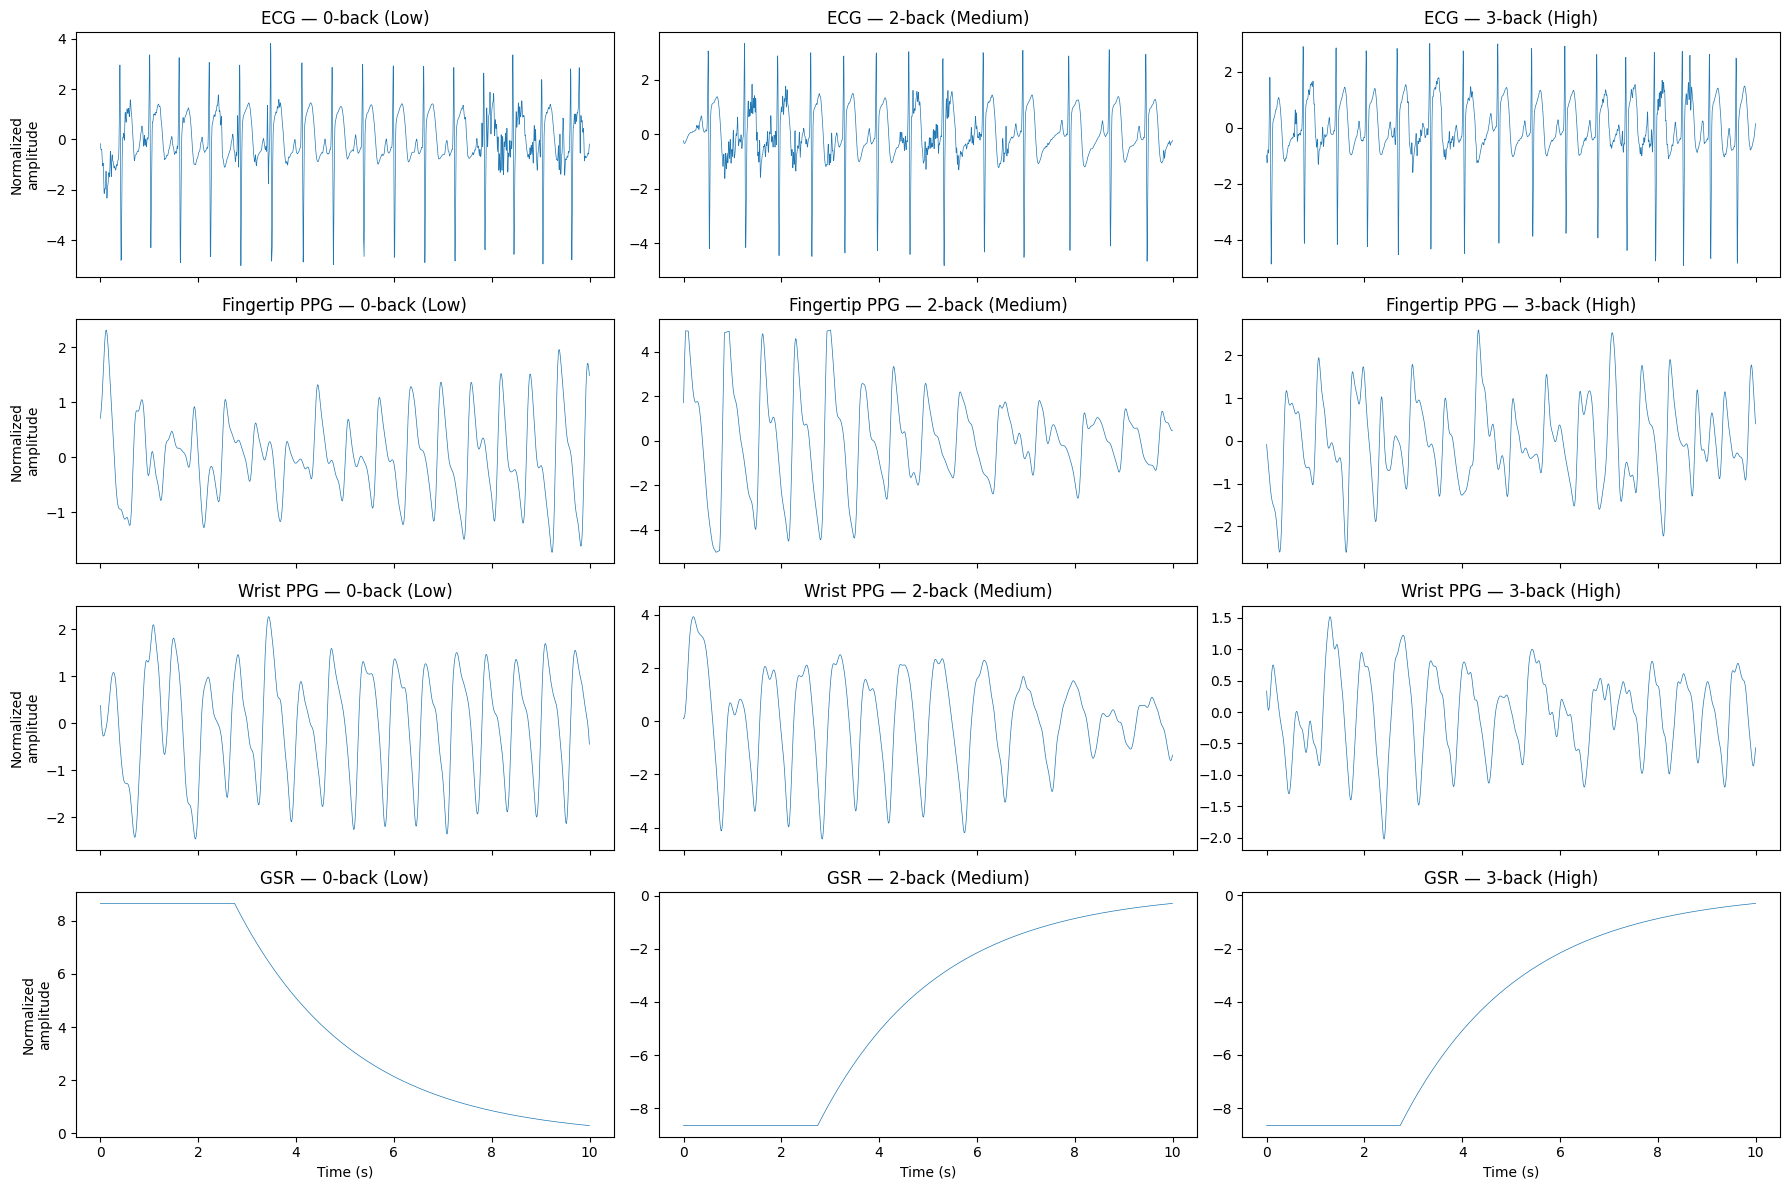

Saved sample_windows.png


In [12]:
import matplotlib.pyplot as plt

condition_names = {0: '0-back (Low)', 1: '2-back (Medium)', 2: '3-back (High)'}
modality_names = ['ECG', 'Fingertip PPG', 'Wrist PPG', 'GSR']
modality_arrays = [X_ecg, X_ppg_inf, X_ppg_pix, X_gsr]

fig, axes = plt.subplots(4, 3, figsize=(18, 12), sharex=True)
time_axis = np.arange(W) / FS_TARGET  # seconds

for row, (mod_name, X_mod) in enumerate(zip(modality_names, modality_arrays)):
    for col, label_val in enumerate([0, 1, 2]):
        ax = axes[row, col]
        # Find first clean window with this label
        idx = np.where((y == label_val) & is_clean)[0]
        if len(idx) > 0:
            ax.plot(time_axis, X_mod[idx[0], 0, :], linewidth=0.5)
        ax.set_title(f"{mod_name} — {condition_names[label_val]}")
        if row == 3:
            ax.set_xlabel('Time (s)')
        if col == 0:
            ax.set_ylabel('Normalized\namplitude')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'sample_windows.png'), dpi=150)
plt.show()
print("Saved sample_windows.png")

## 12. Signal Quality Summary

Report per-participant artifact statistics. This helps identify which participants
or modalities might drive uncertainty in the downstream model.

In [13]:
quality_rows = []
for pid in PARTICIPANT_IDS:
    pid_mask = participants == pid
    quality_rows.append({
        'participant': pid,
        'total_windows': pid_mask.sum(),
        'clean_windows': (pid_mask & is_clean).sum(),
        'clean_ratio': (pid_mask & is_clean).sum() / max(pid_mask.sum(), 1),
        'mean_artifact_ratio': artifact_ratios[pid_mask].mean(),
        'max_artifact_ratio': artifact_ratios[pid_mask].max(),
    })

df_quality = pd.DataFrame(quality_rows)
print(df_quality.to_string(index=False))
print()
print(f"Overall clean window rate: {is_clean.mean():.2%}")
df_quality.to_csv(os.path.join(OUTPUT_DIR, 'signal_quality.csv'), index=False)

participant  total_windows  clean_windows  clean_ratio  mean_artifact_ratio  max_artifact_ratio
        002            354            354          1.0             0.000001            0.000391
        003            354            354          1.0             0.000000            0.000000
        004            354            354          1.0             0.000710            0.004688
        005            354            354          1.0             0.000717            0.004297
        006            354            354          1.0             0.000002            0.000391
        008            354            354          1.0             0.006352            0.014062
        010            354            354          1.0             0.005371            0.012109
        011            354            354          1.0             0.000863            0.007422
        012            354            354          1.0             0.008600            0.016406
        013            354            35

## 13. Quick Verification: Load Saved Data

Verify the saved `.npz` files load correctly.

In [14]:
# Verify loading
data = np.load(os.path.join(OUTPUT_DIR, 'windowed_data.npz'))
splits = np.load(os.path.join(OUTPUT_DIR, 'splits.npz'), allow_pickle=True)

print("Loaded windowed_data.npz:")
for key in data.files:
    print(f"  {key}: {data[key].shape} ({data[key].dtype})")

print("\nLoaded splits.npz:")
for key in splits.files:
    print(f"  {key}: {splits[key].shape}")

print("\n--- Preprocessing complete ---")
print(f"Ready for model training with {data['y'].shape[0]} windows across 4 modalities.")
print(f"Deployment configs to test:")
print(f"  1. In-domain:      Train & test on same modality (e.g., X_ppg_pix)")
print(f"  2. Cross-modality: Train on X_ecg -> Test on X_ppg_pix")
print(f"  3. Sensor fusion:  Train on X_ppg_gsr (PPG+GSR) or X_fused (all 4)")

Loaded windowed_data.npz:
  X_ecg: (7788, 1, 2560) (float32)
  X_ppg_inf: (7788, 1, 2560) (float32)
  X_ppg_pix: (7788, 1, 2560) (float32)
  X_gsr: (7788, 1, 2560) (float32)
  X_fused: (7788, 4, 2560) (float32)
  X_ppg_gsr: (7788, 3, 2560) (float32)
  y: (7788,) (int64)
  participants: (7788,) (<U3)
  trial_ids: (7788,) (int64)
  is_clean: (7788,) (bool)
  artifact_ratios: (7788,) (float32)

Loaded splits.npz:
  train_mask: (7788,)
  cal_mask: (7788,)
  test_mask: (7788,)
  train_pids: (14,)
  cal_pids: (4,)
  test_pids: (4,)

--- Preprocessing complete ---
Ready for model training with 7788 windows across 4 modalities.
Deployment configs to test:
  1. In-domain:      Train & test on same modality (e.g., X_ppg_pix)
  2. Cross-modality: Train on X_ecg -> Test on X_ppg_pix
  3. Sensor fusion:  Train on X_ppg_gsr (PPG+GSR) or X_fused (all 4)
